In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, datasets
from tensorflow.keras import datasets
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support

# Ensure reproducibility
np.random.seed(42)
tf.random.set_seed(42)

In [ ]:
# Load dataset
(X_train, y_train), (X_test, y_test) = datasets.cifar10.load_data()

# Class names
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# Normalize pixel values
X_train_norm = X_train.astype('float32') / 255.0
X_test_norm = X_test.astype('float32') / 255.0

# Reshape labels for indexing
y_train_flat = y_train.flatten()
y_test_flat = y_test.flatten()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1444s 8us/step


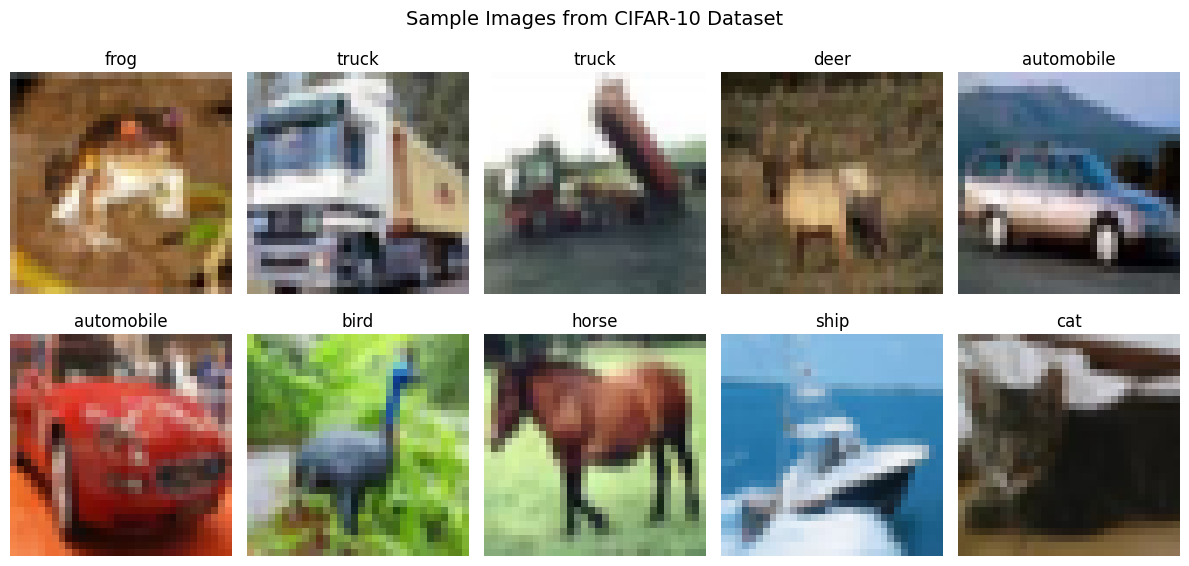

/tmp/ipykernel_603/2525411074.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train_flat, palette='viridis')


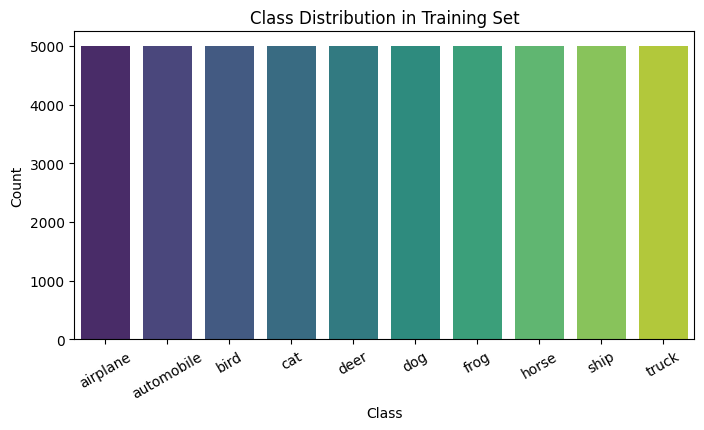

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i])
    ax.set_title(class_names[y_train_flat[i]])
    ax.axis('off')
plt.suptitle("Sample Images from CIFAR-10 Dataset", fontsize=14)
plt.tight_layout()
plt.show()

# Class distribution plot
plt.figure(figsize=(8, 4))
sns.countplot(x=y_train_flat, palette='viridis')
plt.xticks(ticks=range(10), labels=class_names, rotation=30)
plt.title("Class Distribution in Training Set")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [ ]:
def build_cnn():
    model = models.Sequential([
        # Block 1: Low-level features (edges, colors)
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3), name='conv_1'),
        layers.MaxPooling2D((2, 2), name='pool_1'),

        # Block 2: Mid-level features (textures, shapes)
        layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv_2'),
        layers.MaxPooling2D((2, 2), name='pool_2'),

        # Block 3: High-level features (object parts)
        layers.Conv2D(128, (3, 3), activation='relu', padding='same', name='conv_3'),
        layers.MaxPooling2D((2, 2), name='pool_3'),

        # Fully Connected Classifier
        layers.Flatten(name='flatten'),
        layers.Dense(128, activation='relu', name='fc_1'),
        layers.Dropout(0.3, name='dropout'),
        layers.Dense(10, activation='softmax', name='output')
    ])
    return model

cnn_model = build_cnn()
cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_1 (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_1 (MaxPooling2D)           │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv2D)                 │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_2 (MaxPooling2D)           │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_3 (Conv2D)                 │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_3 (MaxPooling2D)           │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc_1 (Dense)                    │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,810 (1.36 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Hyperparameters
BATCH_SIZE = 64
EPOCHS = 15

# Model Training
history = cnn_model.fit(
    X_train_norm, y_train_flat,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test_norm, y_test_flat),
    verbose=1
)

Epoch 1/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - accuracy: 0.4400 - loss: 1.5430 - val_accuracy: 0.5991 - val_loss: 1.1437
Epoch 2/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6015 - loss: 1.1220 - val_accuracy: 0.6719 - val_loss: 0.9516
Epoch 3/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6683 - loss: 0.9457 - val_accuracy: 0.7027 - val_loss: 0.8546
Epoch 4/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7061 - loss: 0.8356 - val_accuracy: 0.7170 - val_loss: 0.8188
Epoch 5/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7384 - loss: 0.7477 - val_accuracy: 0.7323 - val_loss: 0.7801
Epoch 6/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7619 - loss: 0.6835 - val_accuracy: 0.7278 - val_loss: 0.8053
Epoch 7/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7826 - loss: 0.6200 - val_accuracy: 0.7436 - val_loss: 0.7712
Epoch 8/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7970 - loss: 0.5705 - val_accuracy: 

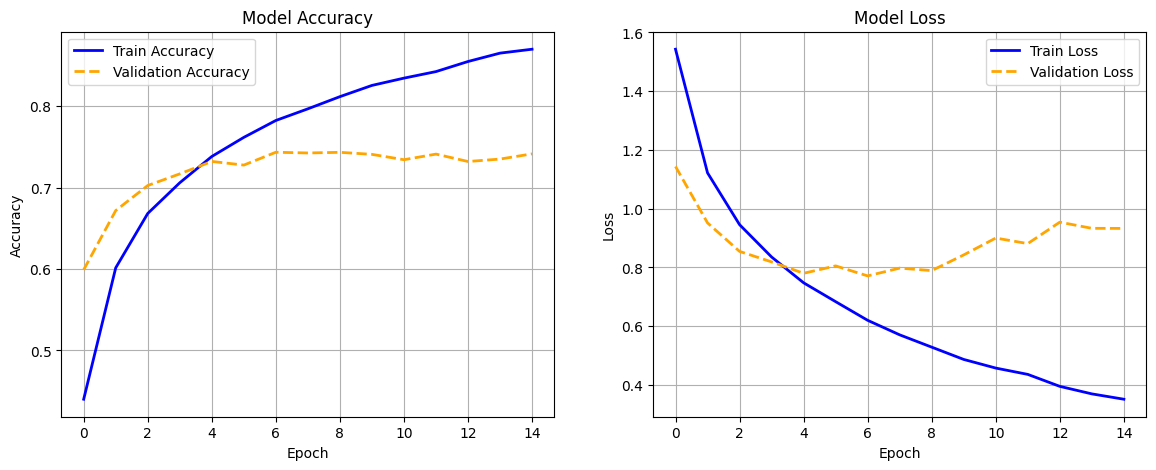

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy Curve
ax1.plot(history.history['accuracy'], label='Train Accuracy', color='blue', linewidth=2)
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange', linestyle='--', linewidth=2)
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Loss Curve
ax2.plot(history.history['loss'], label='Train Loss', color='blue', linewidth=2)
ax2.plot(history.history['val_loss'], label='Validation Loss', color='orange', linestyle='--', linewidth=2)
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.show()

In [ ]:
def build_cnn():
    model = models.Sequential([
        # Explicit input layer solves this permanently across all of Keras
        layers.Input(shape=(32, 32, 3)),

        layers.Conv2D(32, (3, 3), activation='relu', padding='same', name='conv_1'),
        layers.MaxPooling2D((2, 2), name='pool_1'),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv_2'),
        layers.MaxPooling2D((2, 2), name='pool_2'),
        layers.Conv2D(128, (3, 3), activation='relu', padding='same', name='conv_3'),
        layers.MaxPooling2D((2, 2), name='pool_3'),
        layers.Flatten(name='flatten'),
        layers.Dense(128, activation='relu', name='fc_1'),
        layers.Dropout(0.3, name='dropout'),
        layers.Dense(10, activation='softmax', name='output')
    ])
    return model

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


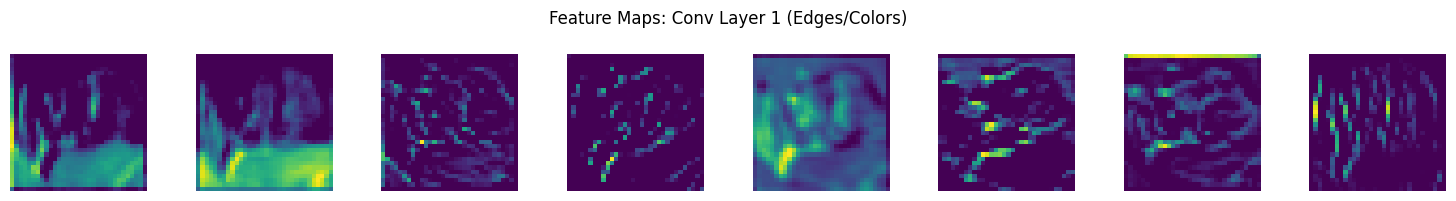

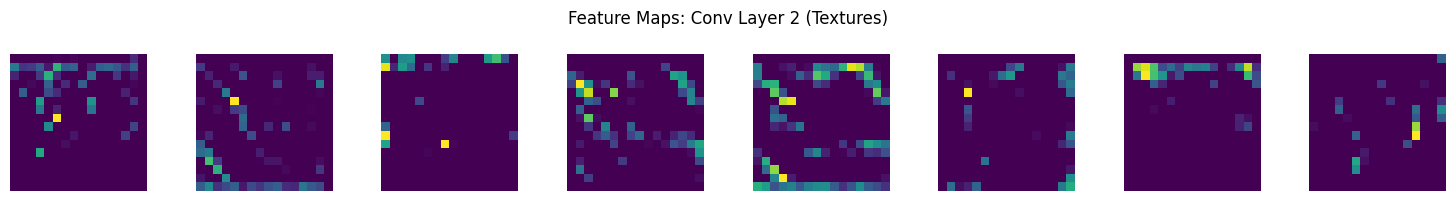

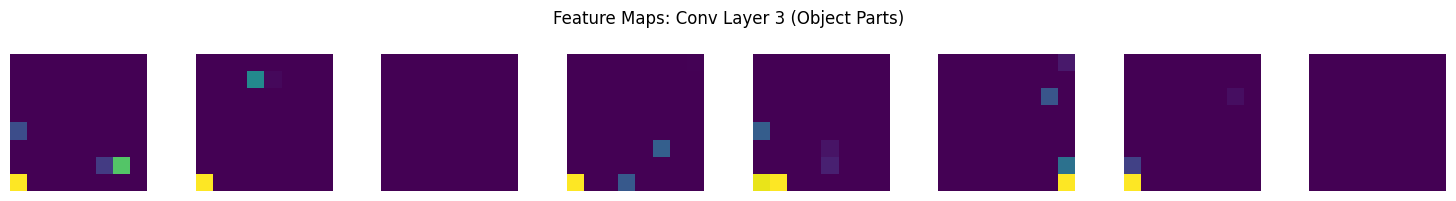

In [ ]:
import matplotlib.pyplot as plt
from tensorflow.keras import models

# Select sample image
sample_img = X_test_norm[0:1] # Shape: (1, 32, 32, 3)

# 1. Build extractor using cnn_model.inputs (plural) or model layers directly
try:
    layer_outputs = [cnn_model.get_layer(name).output for name in ['conv_1', 'conv_2', 'conv_3']]
    activation_model = models.Model(inputs=cnn_model.inputs, outputs=layer_outputs)
    activations = activation_model.predict(sample_img)
except AttributeError:
    # Fail-safe for Keras 3 sequential models: pass image step-by-step through layers
    activations = []
    x = sample_img
    for layer in cnn_model.layers:
        x = layer(x)
        if layer.name in ['conv_1', 'conv_2', 'conv_3']:
            activations.append(x.numpy())

# 2. Visualize feature maps
layer_names = ['Conv Layer 1 (Edges/Colors)', 'Conv Layer 2 (Textures)', 'Conv Layer 3 (Object Parts)']
for layer_idx, feature_map in enumerate(activations):
    num_features = 8 # Visualize first 8 filters
    fig, axes = plt.subplots(1, num_features, figsize=(15, 2))
    for i in range(num_features):
        axes[i].imshow(feature_map[0, :, :, i], cmap='viridis')
        axes[i].axis('off')
    plt.suptitle(f"Feature Maps: {layer_names[layer_idx]}", fontsize=12)
    plt.tight_layout()
    plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
================ Classification Report ================
              precision    recall  f1-score   support

    airplane       0.70      0.86      0.77      1000
  automobile       0.88      0.85      0.86      1000
        bird       0.62      0.68      0.65      1000
         cat       0.60      0.49      0.54      1000
        deer       0.69      0.71      0.70      1000
         dog       0.60      0.68      0.64      1000
        frog       0.84      0.76      0.80      1000
       horse       0.81      0.76      0.79      1000
        ship       0.86      0.82      0.84      1000
       truck       0.86      0.80      0.83      1000

    accuracy                           0.74     10000
   macro avg       0.75      0.74      0.74     10000
weighted avg       0.75      0.74      0.74     10000



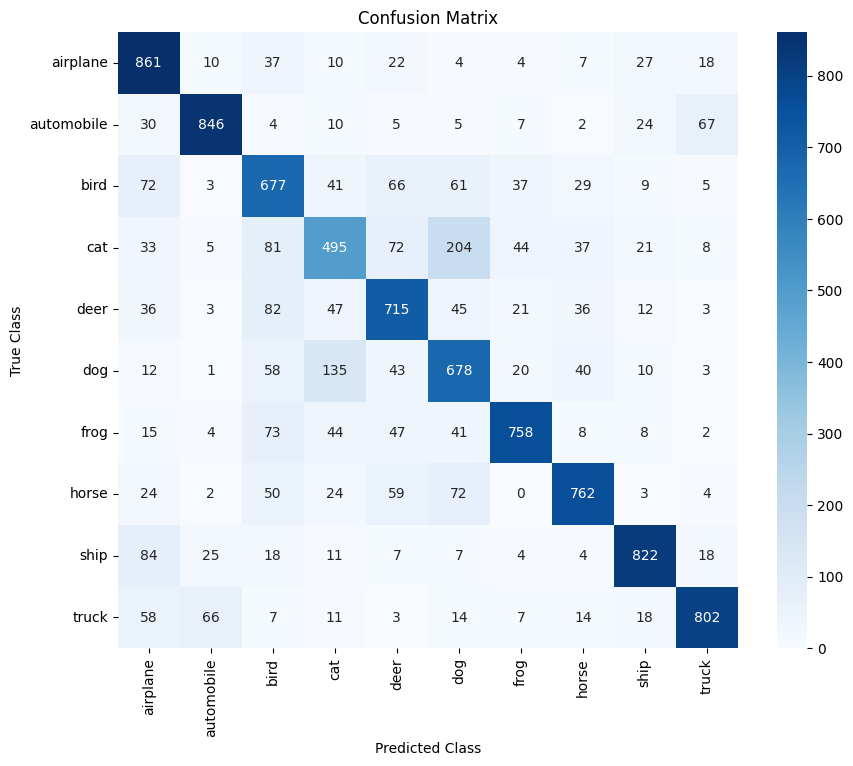

In [ ]:
# Generate Predictions
y_pred_probs = cnn_model.predict(X_test_norm)
y_pred = np.argmax(y_pred_probs, axis=1)

# Classification Report
print("================ Classification Report ================")
print(classification_report(y_test_flat, y_pred, target_names=class_names))

# Confusion Matrix Visualisation
cm = confusion_matrix(y_test_flat, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.show()